# Wissal Portion of ML Project

In [1]:
from sklearn.neural_network import MLPRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

TRAIN_PATH = 'train_data.csv'
VAL_PATH   = 'val_data.csv'
TEST_PATH  = 'test_data.csv'
OUTPUT_DIR = './' 

NUMERIC_FEATURES = [
    'ReturnBid1', 'ReturnAsk1',
    'DerivativeReturnBid1', 'DerivativeReturnAsk1',
    'BidSize1', 'AskSize1',
    'TradeBidSize', 'TradeAskSize',
    'CancelledBidSize', 'CancelledAskSize',
    'TradeBidIndicator', 'TradeAskIndicator',
    'CancelledBidIndicator', 'CancelledAskIndicator',
]


In [4]:
print("Loading data.")
train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)
test  = pd.read_csv(TEST_PATH)


normal = pd.concat([train, val], ignore_index=True)

print(f"  Train: {len(train):>10,} rows  (all normal)")
print(f"  Val: {len(val):>10,} rows  (all normal)")
print(f"  Normal : {len(normal):>10,} rows  combined — used for ALL fitting")
print(f"  Test: {len(test):>10,} rows  (contains hidden fraud — never used for fitting)")

Loading data.
  Train:  1,070,022 rows  (all normal)
  Val:    467,939 rows  (all normal)
  Normal :  1,537,961 rows  combined — used for ALL fitting
  Test:    289,101 rows  (contains hidden fraud — never used for fitting)


In [5]:
def add_burst_features(df):
    """
    Count how many sub-orders share the same base OriginalSequenceNumber.
    Burst orders of size 10-49 have 175x higher mean |ReturnBid1| than
    single orders — the strongest fraud signal we found in EDA.
    Note: burst_size is computed within each dataset independently,
    so there is no leakage from test into train.
    """
    df = df.copy()
    df['base_seq']     = df['OriginalSequenceNumber'].astype(str).str.split('-').str[0]
    burst              = df.groupby('base_seq').size().rename('burst_size')
    df                 = df.join(burst, on='base_seq')
    df['burst_log']    = np.log1p(df['burst_size'])
    df['burst_10_49']  = ((df['burst_size'] >= 10) & (df['burst_size'] < 50)).astype(float)
    df['burst_50plus'] = (df['burst_size'] >= 50).astype(float)
    return df


def compute_training_stats(normal_df):
    """
    Compute per-symbol mean and std from NORMAL DATA ONLY.
    These stats are then applied to the test set — we never compute
    stats from the test set itself (that would be data leakage).
    """
    filled = normal_df[NUMERIC_FEATURES].fillna(0)
    stats  = {}
    for sym in normal_df['ExternalSymbol'].unique():
        mask = (normal_df['ExternalSymbol'] == sym).values
        sub  = filled.values[mask]
        stats[sym] = {
            col: (sub[:, j].mean(), max(sub[:, j].std(), 1e-9))
            for j, col in enumerate(NUMERIC_FEATURES)
        }
    stats['__global__'] = {
        col: (filled[col].mean(), max(filled[col].std(), 1e-9))
        for col in NUMERIC_FEATURES
    }
    return stats


def compute_zscores(df, stats):
    """
    |z| = |value - training_mean| / training_std  (per symbol).
    Uses training stats only — no leakage.
    """
    filled  = df[NUMERIC_FEATURES].fillna(0).values
    zscores = np.zeros_like(filled)
    for sym in df['ExternalSymbol'].unique():
        mask      = (df['ExternalSymbol'] == sym).values
        sym_stats = stats.get(sym, stats['__global__'])
        for j, col in enumerate(NUMERIC_FEATURES):
            mu, sig          = sym_stats[col]
            zscores[mask, j] = np.abs((filled[mask, j] - mu) / sig)
    return zscores


def engineer_features(df, stats):
    """Build full feature matrix from raw LOB columns."""
    df = df.copy()
    df[NUMERIC_FEATURES] = df[NUMERIC_FEATURES].fillna(0)
    zscores = compute_zscores(df, stats)
    df['max_zscore']  = zscores.max(axis=1)
    df['mean_zscore'] = zscores.mean(axis=1)
    for j, col in enumerate(NUMERIC_FEATURES):
        df[f'z_{col}'] = zscores[:, j]
    df['max_abs_feat']  = df[NUMERIC_FEATURES].abs().max(axis=1)
    df['abs_RetBid1']   = df['ReturnBid1'].abs()
    df['abs_RetAsk1']   = df['ReturnAsk1'].abs()
    df['return_spread'] = (df['ReturnBid1'] - df['ReturnAsk1']).abs()
    feat_cols = (
        NUMERIC_FEATURES
        + ['max_zscore', 'mean_zscore']
        + [f'z_{c}' for c in NUMERIC_FEATURES]
        + ['max_abs_feat', 'abs_RetBid1', 'abs_RetAsk1', 'return_spread']
        + ['burst_log', 'burst_10_49', 'burst_50plus']
    )
    return df, df[feat_cols].fillna(0).values


# Run feature engineering 
stats = compute_training_stats(normal)

normal = add_burst_features(normal)
test   = add_burst_features(test)

normal, X_normal = engineer_features(normal, stats)
test,   X_test   = engineer_features(test,   stats)

print(f"\nFeature matrix shapes:")
print(f"  Normal: {X_normal.shape}  - used to FIT models")
print(f"  Test: {X_test.shape} -  used only for SCORING")


Feature matrix shapes:
  Normal: (1537961, 37)  - used to FIT models
  Test: (289101, 37) -  used only for SCORING


In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler

z_sc   = (lambda df: (lambda s: (s-s.min())/(s.max()-s.min()+1e-9))(
    3.0*np.log1p(df['max_zscore'].values) + 1.0*np.log1p(df['mean_zscore'].values)
    + 8.0*df['burst_10_49'].values + 4.0*df['burst_50plus'].values
    + 1.0*df['burst_log'].values   + 0.5*np.log1p(df['abs_RetBid1'].values)))(test)

scaler = RobustScaler()
X_n_sc = scaler.fit_transform(X_normal)   # fit on normal only
X_t_sc = scaler.transform(X_test)

iforest = IsolationForest(n_estimators=400, max_samples=512,
                          contamination=0.01, n_jobs=-1, random_state=42)
iforest.fit(X_n_sc)
if_sc = (lambda a: (a-a.min())/(a.max()-a.min()+1e-9))(-iforest.score_samples(X_t_sc))
print(f"z-score > 0.5: {(z_sc > 0.5).sum():,} | IF > 0.5: {(if_sc > 0.5).sum():,}")


z-score > 0.5: 26,240 | IF > 0.5: 41,895


In [7]:
print("Training Dense Autoencoder on normal data...")
print("Architecture: 37 → 20 → 8 → 20 → 37")
print(f"Training samples: {len(X_n_sc):,}")

autoencoder = MLPRegressor(
    hidden_layer_sizes = (20, 8, 20),
    activation= 'relu',
    solver= 'adam',
    learning_rate_init = 0.001,
    max_iter= 50,
    batch_size= 1024,
    random_state = 42,
    verbose = False,
)
autoencoder.fit(X_n_sc, X_n_sc)   # ← input = output = autoencoder trick
print(f"Done  Final loss: {autoencoder.loss_:.6f}")


Training Dense Autoencoder on normal data...
Architecture: 37 → 20 → 8 → 20 → 37
Training samples: 1,537,961
Done  Final loss: 2.663457


In [8]:
# Reconstruction error on test set
X_recon     = autoencoder.predict(X_t_sc)
recon_error = np.mean((X_t_sc - X_recon) ** 2, axis=1)
ae_sc       = (lambda a: (a-a.min())/(a.max()-a.min()+1e-9))(recon_error)

print("Dense AE:")
for t in [0.5, 0.7, 0.9]:
    print(f"  score > {t}: {(ae_sc > t).sum():,} rows")

# Show what the AE adds: rows it catches that z-score misses
only_ae = (ae_sc > 0.7) & (z_sc <= 0.7)
print(f"\nRows only Dense AE catches (score>0.7, z-score<=0.7): {only_ae.sum():,}")
print("These are multivariate outliers with no single extreme feature.")


Dense AE:
  score > 0.5: 1 rows
  score > 0.7: 1 rows
  score > 0.9: 1 rows

Rows only Dense AE catches (score>0.7, z-score<=0.7): 1
These are multivariate outliers with no single extreme feature.


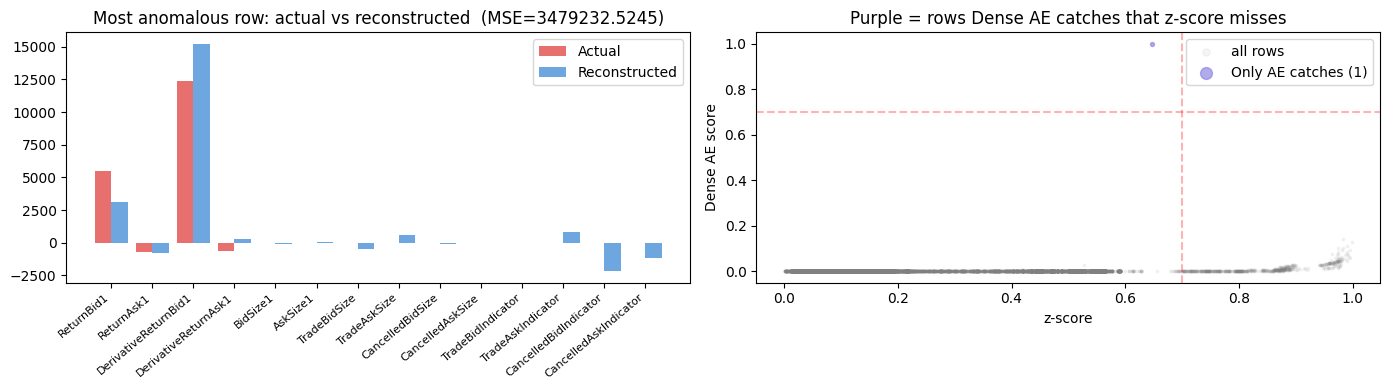

In [9]:
# Compare actual vs reconstructed for the most suspicious row
worst_idx = np.argmax(recon_error)
actual    = X_t_sc[worst_idx]
recon     = X_recon[worst_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x = np.arange(len(NUMERIC_FEATURES))
axes[0].bar(x - 0.2, actual[:len(NUMERIC_FEATURES)],  width=0.4, label='Actual',         color='#E24B4A', alpha=0.8)
axes[0].bar(x + 0.2, recon[:len(NUMERIC_FEATURES)],   width=0.4, label='Reconstructed',  color='#4A90D9', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(NUMERIC_FEATURES, rotation=40, ha='right', fontsize=8)
axes[0].set_title(f'Most anomalous row: actual vs reconstructed  (MSE={recon_error[worst_idx]:.4f})')
axes[0].legend()

axes[1].scatter(z_sc[::10],    ae_sc[::10],    s=3, alpha=0.08, color='gray', label='all rows')
axes[1].scatter(z_sc[only_ae], ae_sc[only_ae], s=8, alpha=0.6,  color='#7F77DD', label=f'Only AE catches ({only_ae.sum():,})')
axes[1].axhline(0.7, color='red', linestyle='--', alpha=0.3)
axes[1].axvline(0.7, color='red', linestyle='--', alpha=0.3)
axes[1].set_xlabel('z-score'); axes[1].set_ylabel('Dense AE score')
axes[1].set_title('Purple = rows Dense AE catches that z-score misses')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}v2_ae_analysis.png', dpi=120, bbox_inches='tight')
plt.show()


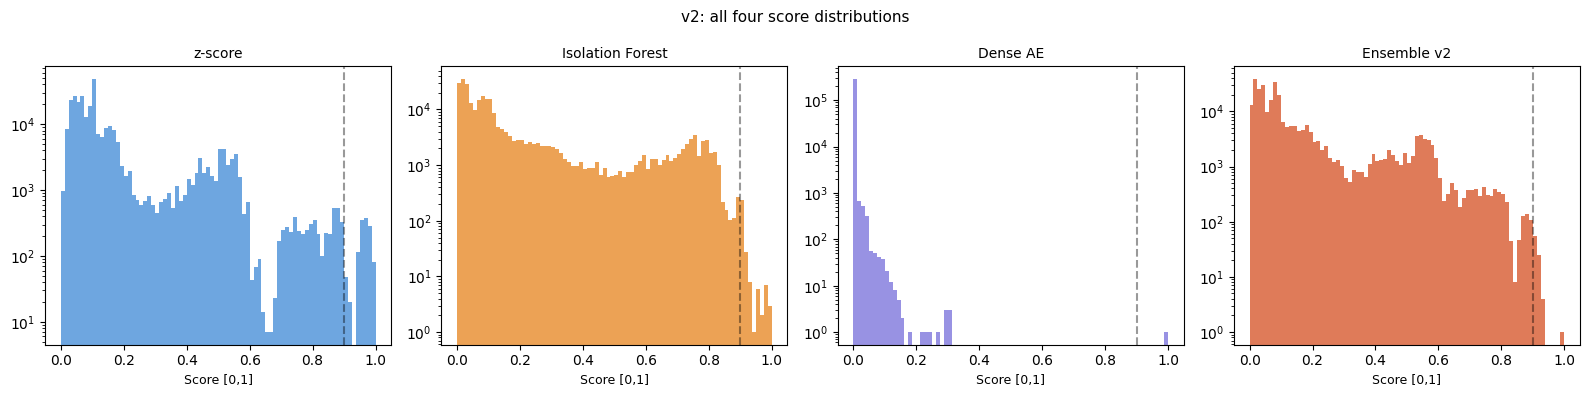

In [10]:
final = 0.50 * z_sc + 0.25 * if_sc + 0.25 * ae_sc
final = (lambda a: (a-a.min())/(a.max()-a.min()+1e-9))(final)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, score, label, color in zip(axes,
    [z_sc, if_sc, ae_sc, final],
    ['z-score', 'Isolation Forest', 'Dense AE', 'Ensemble v2'],
    ['#4A90D9', '#E88B2A', '#7F77DD', '#D85A30']
):
    ax.hist(score, bins=80, color=color, alpha=0.8, edgecolor='none')
    ax.set_title(label, fontsize=10); ax.set_yscale('log')
    ax.set_xlabel('Score [0,1]', fontsize=9)
    ax.axvline(0.9, color='black', linestyle='--', alpha=0.4)

plt.suptitle('v2: all four score distributions', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}v2_scores.png', dpi=120, bbox_inches='tight')
plt.show()


In [11]:
def save_submission(scores, filename):
    sub = pd.DataFrame({'ID': test['index'].values, 'TARGET': scores})
    path = f'{OUTPUT_DIR}{filename}'
    sub.to_csv(path, index=False)
    print(f"\n✅  Saved: {path}")
    print(f"    Rows : {len(sub):,}")
    print(f"    Score range: [{scores.min():.4f}, {scores.max():.4f}]")
    print(f"    Score > 0.9: {(scores > 0.9).sum():,} flagged rows")
    return sub

sub = save_submission(final, 'submission_v2.csv')
print(sub.head())


✅  Saved: ./submission_v2.csv
    Rows : 289,101
    Score range: [0.0000, 1.0000]
    Score > 0.9: 84 flagged rows
   ID    TARGET
0   0  0.072496
1   1  0.470162
2   2  0.540487
3   3  0.573364
4   4  0.540487
